# Exercise 6b - Advanced segmentation. Fisherman's Linear discriminant analysis for segmentation

## Introduction
The exercise is to the extent of the pixel-wise classification problem from being based on the intensity histogram of a single image modality to combining multiple image modalities. Hence, here we wish to segment image features into two classes by training a classifier based on the intensity information from multiple image modalities.
Multiple-image modalities just mean a series of images that contain different but complementary image information of the same object. It is assumed that the image modalities have the same size, so we have a pixel-to-pixel correspondence between the two images. An image feature is an identifiable object in the image e.g., of a dog, moon rocket, or brain tissue types that we wish to segment into individual classes.

Here we aim to segment two types of brain tissues into two feature classes. To improve the segmentation, we wish to combine two MRI image modalities instead of a single: one is a “T1 weighted MRI” and the other is a “T2 weighted MRI”. Both are acquired at the same time. 

Exercise - You simply go step-by-step and fill in the command lines and answer/discuss the questions (Q1-Q12).

## Theory
### The Linear Discriminate Classifier

As a classifier, we will use a class of linear discriminate functions that aims to place a hyperplane in the multi-dimensional feature space that acts as a decision boundary to segment two features into classes. Since we only look at image intensities of two image modalities our multi-dimensional feature space is a 2D intensity histogram. The linear discriminant classifier is based on the Bayesian theory where the posterior probability is the probability of voxel x belonging to class $C_i$. The voxel x belongs to the class with the highest posterior probability. 

You can find an **important** description of the theory behind LDA in - [Exercise theory](theory/Exercise6b_2023_Theory.pdf)

## Learning Objectives

1.	Implement, train and evaluate multi-dimensional segmentation using a Linear Discriminate classifier i.e. Fisherman’ Linear discriminant analysis
2.	To visualise the 1D intensity histograms of two different image modalities that contain different intensity information of the same image features.
3.	To identify the expected intensity thresholds in each of the 1D histograms that best segment the same feature in the two image modalities.
4.	To visualize the 2D histogram of two image modalities that map the same object but with different intensity information.
5.	To interpret the 2D histogram information by identifying clusters of 2D intensity distributions and relate these to features in the images.
6.	To draw an expected linear hyper plane in the 2D histogram that best segment and feature in the two image modalities
7.	To extract training data sets and their corresponding class labels from expert drawn regions-of-interest data, and map their corresponding 2D histogram for visual inspection
8.	To relate the Bayesian theory to a linear discriminate analysis classifier for estimating class probabilities of segmented features.
9.	To judge if the estimated linear or a non-linear hyper plane is optimal placed for robust segmentation of two classes.

## Installing Python packages

In this exercise, we will be using numpy, scipy and scikit-image. You should have these libraries installed, else instructions can be found in the previous exercises.

We will use the virtual environment from the previous exercise (course02503).

## Exercise data and material

The data and material needed for this exercise can be found here:

- [Exercise data](data)

ex6_ImgData2Load.mat contains all image and ROI data which are loaded into
the variables:

- **ImgT1** One axial slice of brain using T1W MRI acquisition
- **ImgT2** One axial slice of brain using T2W MRI acquisition
- **ROI_WM** Binary training data for class 1: Expert identification of voxels belonging to tissue type: White Matter
- **ROI_GM** Binary training data for class 2: Expert identification of voxels belonging to tissue type: Grey Matter

LDA.py A python function that realise the Fisher's linear discriminant analyse as described in Note for the lecture.

# Image Segmentation

Start by importing some useful functions:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

And the data:

In [ ]:
in_dir = '../data/'
in_file = 'ex6_ImagData2Load.mat'
data = sio.loadmat(in_dir + in_file)
ImgT1 = data['ImgT1']
ImgT2 = data['ImgT2']
ROI_GM = data['ROI_GM'].astype(bool)
ROI_WM = data['ROI_WM'].astype(bool)

## Exercise 1 
Display both the T1 and T2 images, their 1 and 2D histograms and scatter plots.
Tips: Use the `plt.imshow()`, `plt.hist()`, `plt.hist2d()` and `plt.scatter()` functions
Add relevant title and label for each axis. One can use `plt.subplots()` to show more subfigures in the same figure. 



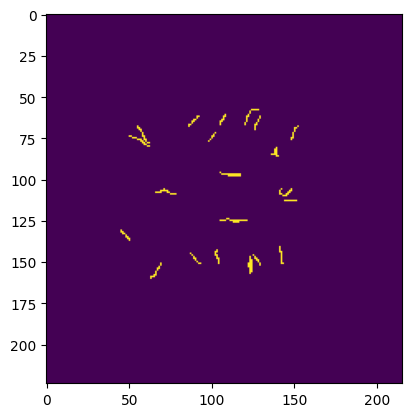

In [23]:
plt.imshow(ROI_GM)

In [24]:
im1WM = ImgT1[ROI_WM>0]

740 172
310 132


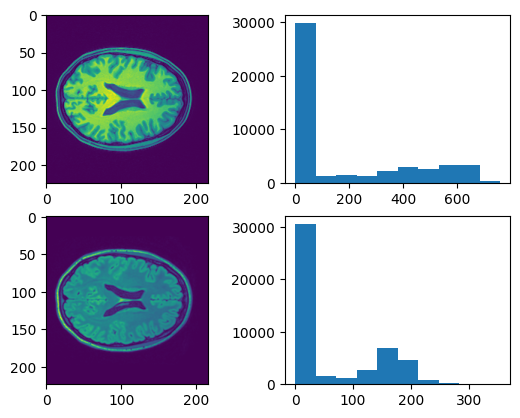

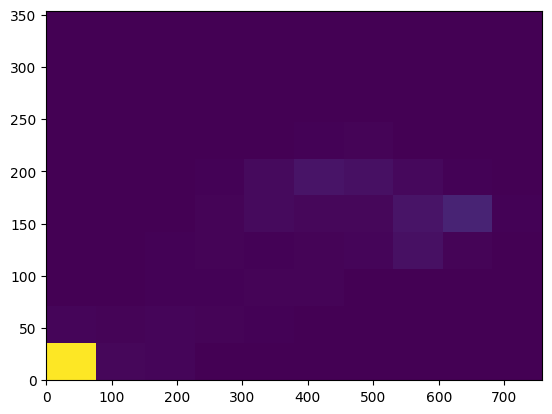

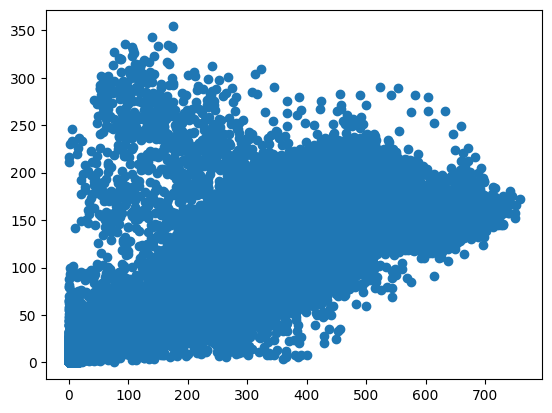

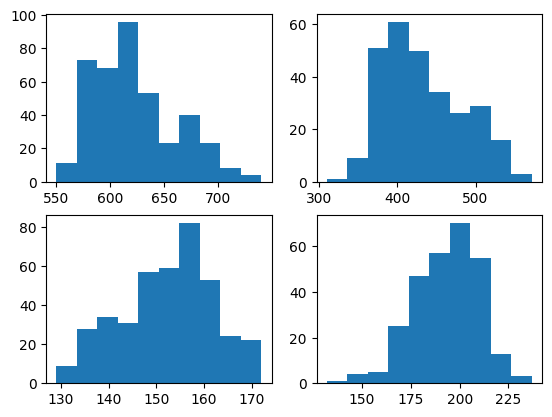

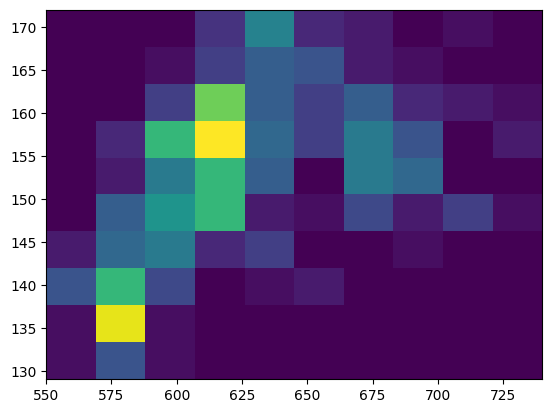

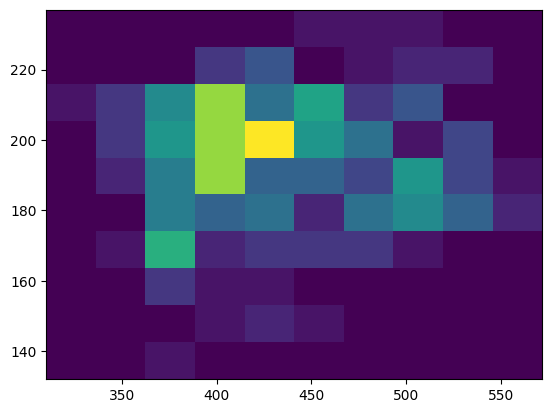

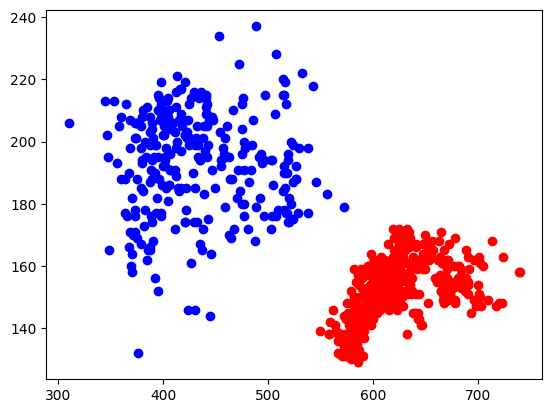

In [29]:
fig, ax = plt.subplots(2,2)
ax[0,0].imshow(ImgT1)
ax[0,1].hist(ImgT1.ravel())
ax[1,0].imshow(ImgT2)
ax[1,1].hist(ImgT2.ravel())


plt.figure()
plt.hist2d(x=ImgT1.ravel(),y=ImgT2.ravel())

plt.figure()
plt.scatter(x=ImgT1.ravel(),y=ImgT2.ravel())




#get white and gray matter information
im1WM = ImgT1[ROI_WM]
im2WM = ImgT2[ROI_WM]
im1GM = ImgT1[ROI_GM]
im2GM = ImgT2[ROI_GM]

fig, ax = plt.subplots(2,2)
ax[0,0].hist(im1WM.ravel())
ax[0,1].hist(im1GM.ravel())
ax[1,0].hist(im2WM.ravel())
ax[1,1].hist(im2GM.ravel())

print(im1WM.ravel().max(), im2WM.ravel().max())
print(im1GM.ravel().min(), im2GM.ravel().min())

plt.figure()
plt.hist2d(im1WM,im2WM)


plt.figure()
plt.hist2d(im1GM,im2GM)

plt.figure()
plt.scatter(x=im1WM.ravel(),y=im2WM.ravel(),color="red")
plt.scatter(x=im1GM.ravel(),y=im2GM.ravel(),color="blue")




**Remove intensities from background voxels for 1D and 2D histograms.**

![imshow image coordinates](figs/Picture1.png)

The two MRI image modalities contain different types of intensity classes:

1. (Orange): The White Matter (WM) is the tissue type that contain the brain network - like the cables in the internet. The  WM ensure the communication flow between functional brain regions.
2. (Yellow): The Grey Matter (GM) is the tissue type that contain the cell bodies at the end of the brain network and are the functional units in the brain. The functional units are like CPUs in the computer. They are processing our sensorial input and are determining a reacting to these. It could be to start running.
3. (Magenta): Cerebrospinal fluid (CSF) which is the water in the brain 
4. (Green): Background of the image

**Q1**: What is the intensity threshold that can separate the GM and WM classes (roughly) from the 1D histograms? 
It seems a threshold of 550 would seperate the classes completely for img1, where > than 550 would be WM. For Im2 it would be somewhere around 160, where lower than 160 is WM. 


**Q2**: Can the GM and WM intensity classes be observed in the 2D histogram and scatter plot?
yes

## Exercise 2
Place trainings examples i.e. ROI_WM and ROI_GM into variables C1 and C2 representing class 1 and class 2 respectively. Show in a figure the manually expert drawings of the C1 and C2 training examples.

*Tips*: use `plt.imshow()`


Text(0.5, 1.0, 'GM')

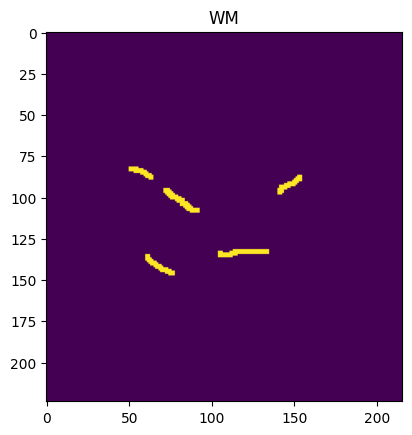

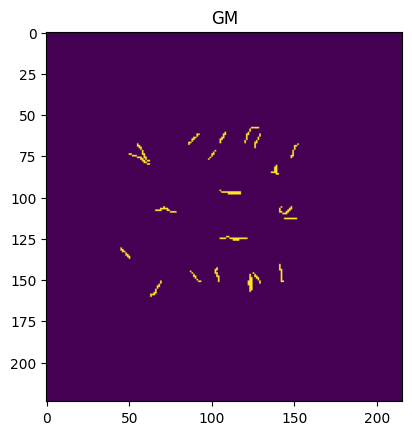

In [33]:
C1 = ROI_WM
C2 = ROI_GM

plt.imshow(C1)
plt.title("WM")
plt.figure()
plt.imshow(C2)
plt.title("GM")






**Q3**: Does the ROI drawings look like what you expect from an expert? 
Looks fine, I think?


## Exercise 3
For each binary training ROI find the corresponding training examples in ImgT1 and ImgT2. Later these will be extracted for LDA training.

*Tips*: If you are a MATLAB-like programming lover, you may use the `np.argwhere()` function appropriately to return the index to voxels in the image full filling e.g. intensity values >0 hence belong to a given class. Name the index variables qC1 and qC2, respectively.



740 172
310 132


(array([[ 0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,  0.],
        [ 0.,  0.,  0.,  1.,  0.,  2.,  3.,  3.,  0.,  0.],
        [ 1.,  0.,  3., 12.,  8.,  8., 10.,  9.,  0.,  0.],
        [ 0.,  1.,  1.,  2.,  6., 16., 16., 16.,  3.,  0.],
        [ 0.,  2.,  1.,  3.,  7.,  6., 19.,  7.,  5.,  0.],
        [ 0.,  1.,  0.,  3.,  2.,  6., 10., 11.,  0.,  1.],
        [ 0.,  0.,  0.,  3.,  7.,  4.,  7.,  3.,  1.,  1.],
        [ 0.,  0.,  0.,  1.,  9., 10.,  1.,  5.,  2.,  1.],
        [ 0.,  0.,  0.,  0.,  6.,  4.,  4.,  0.,  2.,  0.],
        [ 0.,  0.,  0.,  0.,  2.,  1.,  0.,  0.,  0.,  0.]]),
 array([310. , 336.2, 362.4, 388.6, 414.8, 441. , 467.2, 493.4, 519.6,
        545.8, 572. ]),
 array([132. , 142.5, 153. , 163.5, 174. , 184.5, 195. , 205.5, 216. ,
        226.5, 237. ]),
 <matplotlib.collections.QuadMesh at 0x7c5ad733ec10>)

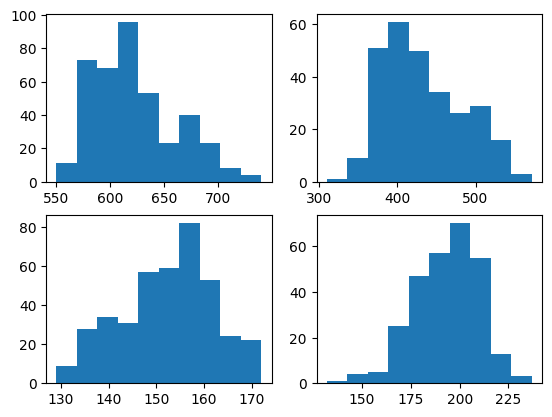

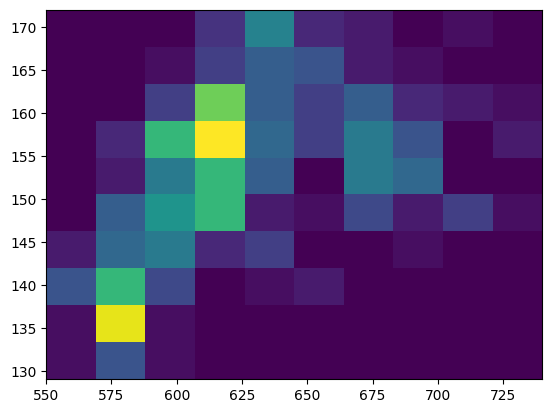

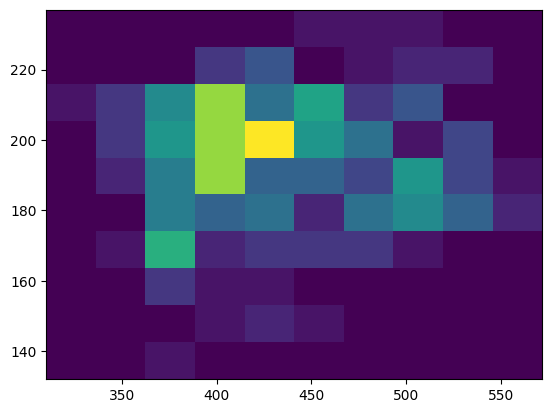

In [ ]:
im1WM = ImgT1[C1] #C1 = WM 
im2WM = ImgT2[C1]
im1GM = ImgT1[C2]
im2GM = ImgT2[C2]

fig, ax = plt.subplots(2,2)
ax[0,0].hist(im1WM.ravel())
ax[0,1].hist(im1GM.ravel())
ax[1,0].hist(im2WM.ravel())
ax[1,1].hist(im2GM.ravel())

print(im1WM.ravel().max(), im2WM.ravel().max())
print(im1GM.ravel().min(), im2GM.ravel().min())

plt.figure()
plt.hist2d(im1WM,im2WM)


plt.figure()
plt.hist2d(im1GM,im2GM)

**Q4**: What is the difference between the 1D histogram of the training examples and the 1D histogram of the whole image? Is the difference expected?
Yes, we remove a lot of 0's (background) and can more clearly see the class-seperation. In the 2D-histogram we notice strong correlation between the two imaging modalities, but they also seem to capture different details (not 1:1 covariance)


## Exercise 4
Make a training data vector (X) and target class vector (T) as input for the `LDA()` function. T and X should have the same length of data points.

**X**: Training data vector should first include all data points for class 1 and then the data points for class 2. Data points are the two input features ImgT1, ImgT2

**T**: Target class identifier for X where '0' are Class 1 and a '1' is Class 2.


X : array-like of shape (n_samples, n_features)
        Training data
    y : array-like of shape (n_samples,)
        Target values.


In [ ]:
#okay, the text is a bit cryptic. What we want is basically a matrix [Im1WM, Im2WM;Im1GM,Im2GM] and the corresponding feature vector y
XWM = np.hstack((im1WM[:,None],im2WM[:,None]))
print(XWM.shape)
XGM = np.hstack((im1GM[:,None],im2GM[:,None]))
print(XGM.shape)
X = np.vstack((XWM,XGM))
print(X.shape)
N = X.shape[0]
y = np.zeros(N).astype(int)
y[XWM.shape[0]:] = 1 #ensure that GM is 1 and WM is 0


(399, 2)
(280, 2)
(679, 2)
280


*Tip: Read the documentation of the provided LDA function to understand the expected input dimensions.*

## Exercise 5 
Make a scatter plot of the training points of the two input features for class 1 and class 2 as green and black circles, respectively. Add relevant title and labels to axis

**Q5**: How does the class separation appear in the 2D scatter plot compared with 1D histogram. Is it better?




Text(0, 0.5, 'Im2')

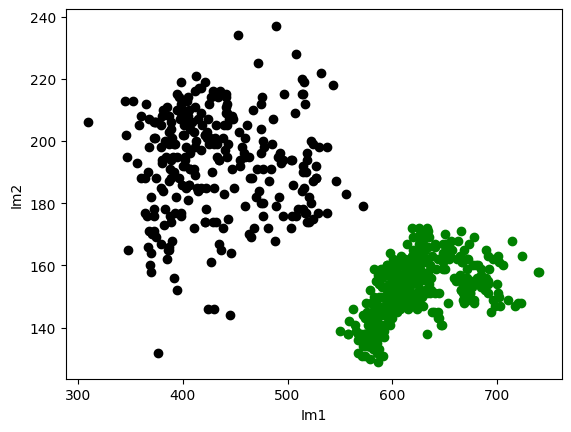

In [68]:
WM_points = X[y==0,:]
GM_points = X[y==1,:]
plt.scatter(WM_points[:,0],WM_points[:,1],color="g",marker="o")
plt.scatter(GM_points[:,0],GM_points[:,1],color="black",marker="o")
plt.xlabel("Im1")
plt.ylabel("Im2")



## Exercise 6
Train the linear discriminant classifier using the Fisher discriminant function and estimate the weight-vector coefficient W (i.e. $w_0$ and $w$) for classification given X and T by using the `W=LDA()` function. The LDA function outputs W=[[w01, w1]; [w02, w2]] for class 1 and 2 respectively.

*Tip: Read the Bishop note on Chapter 4.*

In [ ]:

def LDA(X, y):
    """
    Linear Discriminant Analysis.

    A classifier with a linear decision boundary, generated by fitting class conditional densities to the data and using Bayes’ rule.
    Assumes equal priors among classes

    Parameters
    ----------
    X : array-like of shape (n_samples, n_features)
        Training data
    y : array-like of shape (n_samples,)
        Target values.

    Returns
    -------
    W : array-like of shape (n_classes, n_features+1)
        Weights for making the projection. First column is the constants.

    Last modified: 11/11/22, mcbo@dtu.dk
    """
    
    # Determine size of input data
    n, m = X.shape
    # Discover and count unique class labels
    class_label = np.unique(y)
    k = len(class_label)

    # Initialize
    n_group     = np.zeros((k,1))     # Group counts
    group_mean  = np.zeros((k,m))     # Group sample means
    pooled_cov  = np.zeros((m,m))     # Pooled covariance
    W          = np.zeros((k,m+1))    # Model coefficients

    for i in range(k):
        # Establish location and size of each class
        group      = np.squeeze(y == class_label[i])
        n_group[i]  = np.sum(group.astype(np.double))
        
        # Calculate group mean vectors
        group_mean[i,:] = np.mean(X[group,:], axis = 0)
        
        # Accumulate pooled covariance information
        pooled_cov = pooled_cov + ((n_group[i] - 1) / (n - k) ) * np.cov(X[group,:], rowvar = False)
    
    # Assign prior probabilities
    prior_prob = n_group / n

    # Loop over classes to calculate linear discriminant coefficients
    for i in range(k):
        # Intermediate calculation for efficiency
        temp = group_mean[i,:][np.newaxis] @ np.linalg.inv(pooled_cov)
        
        # Constant
        W[i,0] = -0.5 * temp @ group_mean[i,:].T + np.log(prior_prob[i])
        
        # Linear
        W[i,1:] = temp

    return W


W = LDA(X,y) #first column: bias
print(W)

[[-138.11536977    0.27566672    0.68044071]
 [-131.32787698    0.15900268    0.99568003]]


/tmp/ipykernel_72054/876541652.py:55: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  W[i,0] = -0.5 * temp @ group_mean[i,:].T + np.log(prior_prob[i])


## Exercise 7
Apply the linear discriminant classifier i.e. perform multi-modal classification using the trained weight-vector $W$ for each class: It calculates the linear score $Y$ for **all** image data points within the brain slice i.e. $y(x)= w+w_0$. Actually, $y(x)$ is the $\log(P(Ci|x))$.

In [ ]:
Xall= np.c_[ImgT1.ravel(), ImgT2.ravel()]
Y = np.c_[np.ones((len(Xall), 1)), Xall] @ W.T
#concatenate bias term, i.e. setup data matrix

[[-137.28836962 -130.85086894]
 [-137.28836962 -130.85086894]
 [-137.56403634 -131.00987162]
 ...
 [-137.28836962 -130.85086894]
 [-137.28836962 -130.85086894]
 [-138.11536977 -131.32787698]]


## Exercise 8
Perform multi-modal classification: Calculate the posterior probability i.e. $P(C_1|X)$ of a data point belonging to class 1

*Note: Using Bayes [Eq 1]: Since* $y(x)$ *is the log of the posterior probability [Eq2] we take* $\exp(y(x))$ *to get* $P(C_1|X)=P(X|\mu,\sigma)P(C_1)$ *and divide with the marginal probability* $P(X)$ *as normalisation factor.*

In [76]:
PosteriorProb = np.clip(np.exp(Y) / np.sum(np.exp(Y),1)[:, np.newaxis], 0, 1)

print(PosteriorProb)

[[0.00159784 0.99840216]
 [0.00159784 0.99840216]
 [0.00142215 0.99857785]
 ...
 [0.00159784 0.99840216]
 [0.00159784 0.99840216]
 [0.00112652 0.99887348]]


## Exercise 9
Apply segmentation: Find all voxles in the T1w and T2w image with $P(C_1|X)>0.5$ as belonging to Class 1. You may use the `np.where()` function. Similarly, find all voxels belonging to class 2.



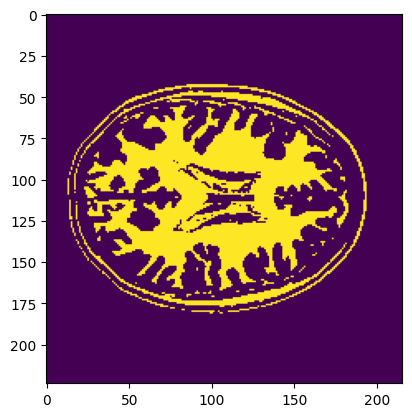

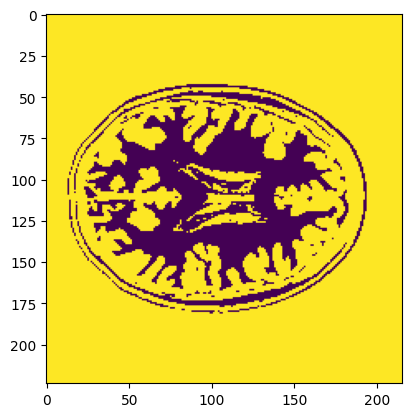

In [89]:
pred_labels = np.argmax(PosteriorProb,axis=1)
label_im_WM = np.zeros_like(pred_labels)
label_im_WM[pred_labels==0] = 1
label_im_WM = label_im_WM.reshape(ImgT1.shape)
label_im_GM = np.zeros_like(pred_labels)
label_im_GM[pred_labels==1] = 1
label_im_GM = label_im_GM.reshape(ImgT1.shape)


plt.figure()
plt.imshow(label_im_WM)
plt.figure()
plt.imshow(label_im_GM)


## Exercise 10
Show scatter plot of segmentation results as in 5.

**Q6** Can you identify where the hyperplane is placed i.e. y(x)=0?

Text(0, 0.5, 'Im2')

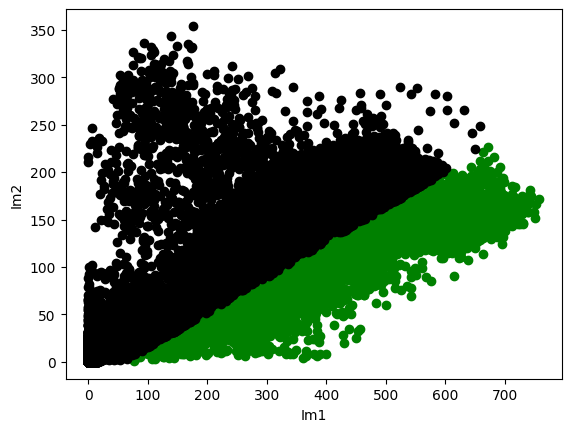

In [90]:

GM_pred_pix = Xall[pred_labels==1]
WM_pred_pix = Xall[pred_labels==0]
plt.scatter(WM_pred_pix[:,0],WM_pred_pix[:,1],color="g",marker="o")
plt.scatter(GM_pred_pix[:,0],GM_pred_pix[:,1],color="black",marker="o")
plt.xlabel("Im1")
plt.ylabel("Im2")



Yes, there is a clear line 



**Q7** Is the linear hyper plane positioned as you expected or would a non-linear hyper plane perform better?


In [101]:
W

array([[-138.11536977,    0.27566672,    0.68044071],
       [-131.32787698,    0.15900268,    0.99568003]])

Text(0, 0.5, 'Im2')

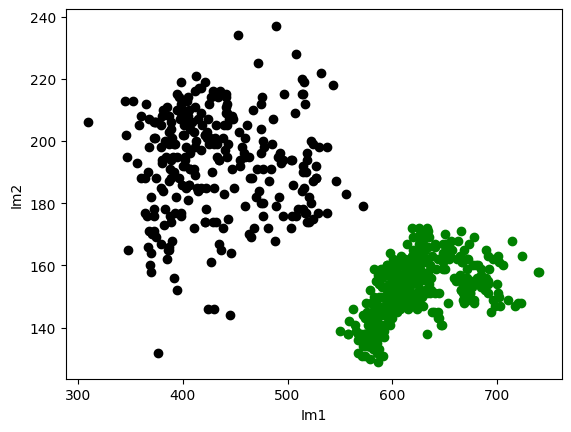

In [ ]:
WM_points = X[y==0,:]
GM_points = X[y==1,:]
plt.scatter(WM_points[:,0],WM_points[:,1],color="g",marker="o")
plt.scatter(GM_points[:,0],GM_points[:,1],color="black",marker="o")
plt.xlabel("Im1")
plt.ylabel("Im2")

#possibly consider drawing the line.. But I cant really figure out how to do that right now
#chat says like this

# # Get LDA coefficients
# w = lda.coef_[0]       # array([w1, w2])
# b = lda.intercept_[0]  # scalar

# # Define a range for x1 (T1 intensities)
# x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 200)

# # Compute corresponding x2 (T2 intensities)
# x2_boundary = -(w[0] * x1_range + b) / w[1]

# # Plot the boundary
# plt.plot(x1_range, x2_boundary, 'r-', linewidth=2, label='LDA decision boundary')
# plt.legend()
# plt.show()




It is placed well based on the data, and there are no data-driven indications for a non-linear hyperplane being a better solution. 
But: a background class should be added. 

**Q8** Would segmentation be as good as using a single image modality using thresholding?
No, it seems there is a strong correlation between modalities and gray/white-status. A threshold on modality 1 would perform better than a threshold on modality 2, but still.. There is not any precise seperation in histograms, so there is no reason to believe a thresholding scheme would work better. 



**Q9** From the scatter plot does the segmentation results make sense? Are the two tissue types segmented correctly.
They do make sense, but: we have the issue that we used binary classification. As such, tons of other tissue has also been classified as white/gray, e.g. background and bone


## Exercise 11

**Q10** Are the training examples representative for the segmentation results? Are you surprised that so few training examples perform so well? Do you need to be an anatomical expert to draw these?

I am surprised. And drawing them is not too hard. Training examples are representative, yes. But obviously, it is important when using this sort of segmentation pipeline that the expert captures many modes of variation of each class in the annotation. As such, it is probably a bit harder usually, and we probably also have some errors in the segmentation which should be tested using dice score. 


**Q11** Compare the segmentation results with the original image. Are the segmentation results satisfactory? Why not?


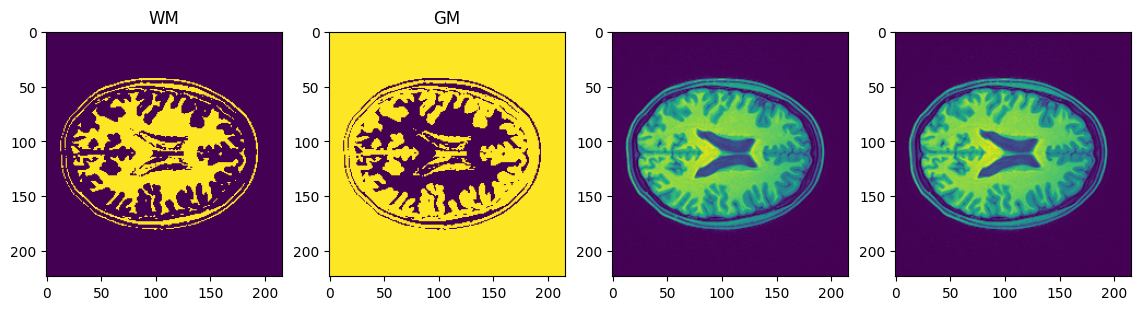

In [ ]:
fig, ax = plt.subplots(1,4,figsize=(14,4))
ax[0].imshow(label_im_WM)
ax[0].set_title("WM")
ax[1].imshow(label_im_GM)
ax[1].set_title("GM")

ax[2].imshow(ImgT1)
ax[3].imshow(ImgT1)


The white-matter segmentation is fair, but obviously contains bone. So it is fairly bad. 
Similarly, CSF has been segmented both as WM and GM (because we didn't include it in the labelling). 
Similarly, background is classified as GM, which is bad. 


**Q12** Is one class completely wrong segmented? What is the problem?
Well, if one considers the relative frequency of misclassifications, GM is classified wrongly in most cases, simply because there are so many background pixels present and we didn't clear these. 
We can check how many percent of the original segmentation we hit though, just to see how well it segments what was actually put in: 


In [100]:
hit_frac_WM = (C1*label_im_WM).sum()/C1.sum()
print(hit_frac_WM)

hit_frac_GM = (C2*label_im_GM).sum()/C2.sum()
print(hit_frac_GM)

1.0
0.9892857142857143


So almost all labels are hit, but seemingly it is better for WM. Obviously, one would usually use dice score or similar for this in a formal setting. 


Notes: time spent: 1hr20 minutes. But had to ask chatGPT - I think the first exercises are very ill formulated, it is hard to understand what they want me to do 